In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
customers = pd.read_csv("Data/customers.csv")
orders = pd.read_csv("Data/orders.csv")
order_items = pd.read_csv("Data/order_items.csv")
products = pd.read_csv("Data/products.csv")

critical_customers = pd.read_csv(
    "Data/critical_customers.csv"
)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
print("Customers:", len(customers))
print("Orders:", len(orders))
print("Order Items:", len(order_items))
print("Products:", len(products))
print("Critical Customers:", len(critical_customers))

Customers: 50000
Orders: 220000
Order Items: 424819
Products: 1000
Critical Customers: 26


Check the critical customer dataset

In [4]:
critical_customers.head(10)

,customer_id,last_order_date,total_orders,total_revenue,recency_days,recency_segment,revenue_percentile,recency_risk_score,value_score,frequency_score,priority_score,priority_segment
0,CUST019255,2025-01-02,9,118694.06,362,Inactive,0.993343,83.257527,99.334328,87.850899,88.999242,Critical Priority
1,CUST000527,2025-02-01,11,100754.20,332,Inactive,0.986000,80.707365,98.599957,93.017554,88.537180,Critical Priority
2,CUST021374,2024-09-20,9,48963.63,466,Inactive,0.864781,89.982944,86.478099,87.850899,88.505081,Critical Priority
3,CUST023638,2025-02-10,10,102612.83,323,Inactive,0.987160,79.869945,98.716035,90.745742,87.698932,Critical Priority
4,CUST022178,2025-02-26,12,96931.92,307,Inactive,0.983394,78.235378,98.339374,94.771753,87.573852,Critical Priority
5,CUST049785,2024-11-06,10,47523.36,419,Inactive,0.856845,87.120081,85.684505,90.745742,87.414541,Critical Priority
6,CUST047664,2024-12-02,8,62362.05,393,Inactive,0.924881,85.472485,92.488096,84.119821,87.306635,Critical Priority
7,CUST043927,2024-11-11,8,55820.01,414,Inactive,0.899083,86.793168,89.908322,84.119821,87.193045,Critical Priority
8,CUST030558,2025-01-20,8,77339.89,344,Inactive,0.961197,81.780494,96.119679,84.119821,86.550115,Critical Priority
9,CUST047284,2024-10-15,6,61035.40,441,Inactive,0.920238,88.520124,92.023784,73.152820,86.497761,Critical Priority


In [5]:
critical_customers.shape

(26, 12)

In [6]:
#Add customer profile information
critical_profile = critical_customers.merge(
    customers,
    on="customer_id",
    how="left"
)

critical_profile.head()

,customer_id,last_order_date,total_orders,total_revenue,recency_days,recency_segment,revenue_percentile,recency_risk_score,value_score,frequency_score,priority_score,priority_segment,signup_date,gender,age,city,state,acquisition_channel,customer_type,income_band
0,CUST019255,2025-01-02,9,118694.06,362,Inactive,0.993343,83.257527,99.334328,87.850899,88.999242,Critical Priority,2025-08-05,Female,44,Chandigarh,Chandigarh,Organic Search,Loyal,Middle
1,CUST000527,2025-02-01,11,100754.20,332,Inactive,0.986000,80.707365,98.599957,93.017554,88.537180,Critical Priority,2025-09-08,Female,38,Lucknow,Uttar Pradesh,Instagram,Loyal,Lower-Middle
2,CUST021374,2024-09-20,9,48963.63,466,Inactive,0.864781,89.982944,86.478099,87.850899,88.505081,Critical Priority,2025-01-17,Female,18,Surat,Gujarat,Organic Search,Loyal,Upper-Middle
3,CUST023638,2025-02-10,10,102612.83,323,Inactive,0.987160,79.869945,98.716035,90.745742,87.698932,Critical Priority,2025-07-10,Male,41,Jaipur,Rajasthan,Referral,Loyal,Middle
4,CUST022178,2025-02-26,12,96931.92,307,Inactive,0.983394,78.235378,98.339374,94.771753,87.573852,Critical Priority,2025-10-14,Female,45,Bengaluru,Karnataka,Organic Search,Loyal,Upper-Middle


In [7]:
critical_profile.columns.tolist()

['customer_id',
 'last_order_date',
 'total_orders',
 'total_revenue',
 'recency_days',
 'recency_segment',
 'revenue_percentile',
 'recency_risk_score',
 'value_score',
 'frequency_score',
 'priority_score',
 'priority_segment',
 'signup_date',
 'gender',
 'age',
 'city',
 'state',
 'acquisition_channel',
 'customer_type',
 'income_band']

In [8]:
#Identify the most valuable critical customers
top_critical_customers = (
    critical_profile
    .sort_values("total_revenue", ascending=False)
    [["customer_id",
      "total_orders",
      "total_revenue",
      "last_order_date",
      "recency_days",
      "priority_score"]]
)

top_critical_customers.head(10)

,customer_id,total_orders,total_revenue,last_order_date,recency_days,priority_score
0,CUST019255,9,118694.06,2025-01-02,362,88.999242
13,CUST049433,9,109248.77,2025-03-01,304,86.215858
3,CUST023638,10,102612.83,2025-02-10,323,87.698932
1,CUST000527,11,100754.20,2025-02-01,332,88.537180
17,CUST038293,6,98927.18,2025-01-09,355,85.518798
4,CUST022178,12,96931.92,2025-02-26,307,87.573852
25,CUST006556,12,91746.60,2025-04-11,263,85.124843
22,CUST046793,9,88149.68,2025-03-09,296,85.378793
20,CUST015131,14,83605.20,2025-04-09,265,85.439793
19,CUST005515,5,79295.73,2024-11-07,418,85.483974


In [9]:
#Critical customers by acquisition channel
critical_by_channel = (
    critical_profile
    .groupby("acquisition_channel")
    .agg(
        critical_customers=("customer_id", "nunique"),
        historical_revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean"),
        avg_recency=("recency_days", "mean")
    )
    .sort_values("historical_revenue", ascending=False)
    .reset_index()
)

critical_by_channel

,acquisition_channel,critical_customers,historical_revenue,avg_revenue,avg_recency
0,Organic Search,8,661670.74,82708.842500,362.125000
1,Google Ads,6,410386.18,68397.696667,372.333333
2,Instagram,5,320647.08,64129.416000,378.000000
3,Referral,3,240988.12,80329.373333,369.333333
4,Affiliate,2,126819.09,63409.545000,418.500000
5,Email,2,106556.45,53278.225000,438.000000


In [10]:
# Revenue exposure by acquisition channel
critical_by_channel["revenue_exposure_pct"] = (
    critical_by_channel["historical_revenue"]
    / critical_by_channel["historical_revenue"].sum()
    * 100
)

critical_by_channel

,acquisition_channel,critical_customers,historical_revenue,avg_revenue,avg_recency,revenue_exposure_pct
0,Organic Search,8,661670.74,82708.842500,362.125000,35.439034
1,Google Ads,6,410386.18,68397.696667,372.333333,21.980252
2,Instagram,5,320647.08,64129.416000,378.000000,17.173833
3,Referral,3,240988.12,80329.373333,369.333333,12.907305
4,Affiliate,2,126819.09,63409.545000,418.500000,6.792421
5,Email,2,106556.45,53278.225000,438.000000,5.707155


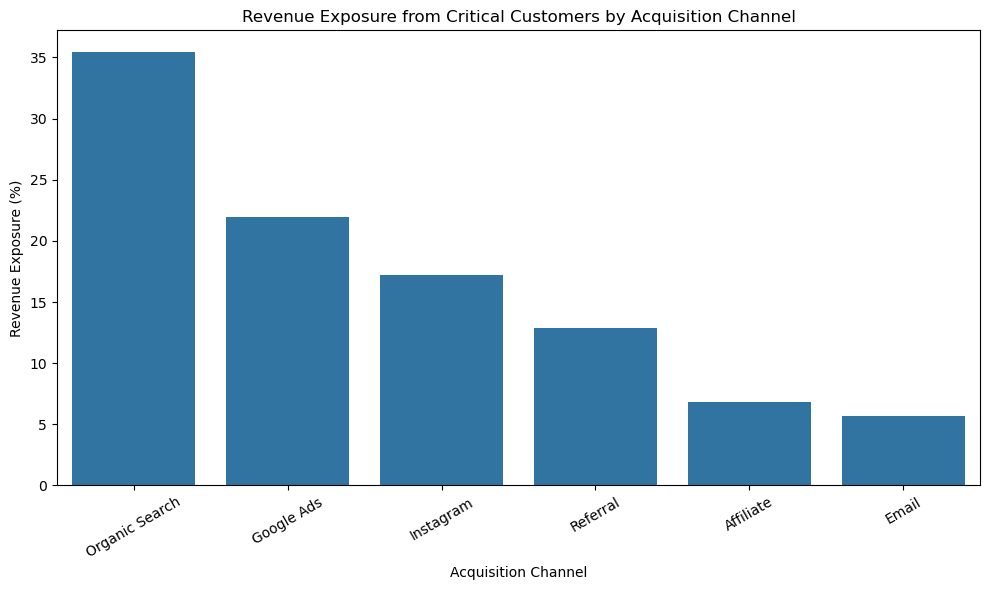

In [11]:
#Visualize revenue exposure
plt.figure(figsize=(10, 6))

sns.barplot(
    data=critical_by_channel,
    x="acquisition_channel",
    y="revenue_exposure_pct"
)

plt.title("Revenue Exposure from Critical Customers by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Revenue Exposure (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [12]:
#Identify the customers requiring immediate action
action_list = (
    critical_profile
    .sort_values(
        ["priority_score", "total_revenue"],
        ascending=[False, False]
    )
    [["customer_id",
      "total_orders",
      "total_revenue",
      "last_order_date",
      "recency_days",
      "priority_score",
      "acquisition_channel"]]
)

action_list.head(10)

,customer_id,total_orders,total_revenue,last_order_date,recency_days,priority_score,acquisition_channel
0,CUST019255,9,118694.06,2025-01-02,362,88.999242,Organic Search
1,CUST000527,11,100754.20,2025-02-01,332,88.537180,Instagram
2,CUST021374,9,48963.63,2024-09-20,466,88.505081,Organic Search
3,CUST023638,10,102612.83,2025-02-10,323,87.698932,Referral
4,CUST022178,12,96931.92,2025-02-26,307,87.573852,Organic Search
5,CUST049785,10,47523.36,2024-11-06,419,87.414541,Affiliate
6,CUST047664,8,62362.05,2024-12-02,393,87.306635,Email
7,CUST043927,8,55820.01,2024-11-11,414,87.193045,Organic Search
8,CUST030558,8,77339.89,2025-01-20,344,86.550115,Referral
9,CUST047284,6,61035.40,2024-10-15,441,86.497761,Referral


In [13]:
#Create an action category
def assign_action(row):

    if row["priority_score"] >= 85:
        return "Immediate Retention"

    elif row["priority_score"] >= 75:
        return "High Priority Outreach"

    else:
        return "Monitor"


action_list["recommended_action"] = action_list.apply(
    assign_action,
    axis=1
)

action_list.head(10)

,customer_id,total_orders,total_revenue,last_order_date,recency_days,priority_score,acquisition_channel,recommended_action
0,CUST019255,9,118694.06,2025-01-02,362,88.999242,Organic Search,Immediate Retention
1,CUST000527,11,100754.20,2025-02-01,332,88.537180,Instagram,Immediate Retention
2,CUST021374,9,48963.63,2024-09-20,466,88.505081,Organic Search,Immediate Retention
3,CUST023638,10,102612.83,2025-02-10,323,87.698932,Referral,Immediate Retention
4,CUST022178,12,96931.92,2025-02-26,307,87.573852,Organic Search,Immediate Retention
5,CUST049785,10,47523.36,2024-11-06,419,87.414541,Affiliate,Immediate Retention
6,CUST047664,8,62362.05,2024-12-02,393,87.306635,Email,Immediate Retention
7,CUST043927,8,55820.01,2024-11-11,414,87.193045,Organic Search,Immediate Retention
8,CUST030558,8,77339.89,2025-01-20,344,86.550115,Referral,Immediate Retention
9,CUST047284,6,61035.40,2024-10-15,441,86.497761,Referral,Immediate Retention


In [14]:
#Final action summary
action_summary = (
    action_list
    .groupby("recommended_action")
    .agg(
        customers=("customer_id", "nunique"),
        revenue_at_risk=("total_revenue", "sum"),
        avg_customer_value=("total_revenue", "mean")
    )
    .sort_values("revenue_at_risk", ascending=False)
    .reset_index()
)

action_summary

,recommended_action,customers,revenue_at_risk,avg_customer_value
0,Immediate Retention,26,1867067.66,71810.294615


In [19]:
# Find orders belonging to Critical customers
critical_orders = orders[
    orders["customer_id"].isin(
        critical_customers["customer_id"]
    )
].copy()

print("Critical customer orders:", len(critical_orders))

Critical customer orders: 246


In [20]:
# Connect orders to order items
critical_order_items = critical_orders[
    ["order_id", "customer_id"]
].merge(
    order_items,
    on="order_id",
    how="inner"
)

print(
    "Critical customer order items:",
    len(critical_order_items)
)

Critical customer order items: 518


In [21]:
critical_order_items.columns.tolist()

['order_id',
 'customer_id',
 'product_id',
 'quantity',
 'selling_price',
 'cost_price',
 'discount']

In [25]:
critical_order_items.head()

,order_id,customer_id,product_id,quantity,selling_price,cost_price_x,discount,product_name,category,sub_category,brand,cost_price_y,list_price,revenue
0,ORD0000666,CUST030558,PROD00422,1,7152.13,3605.47,721.59,Bloom Skincare Model-0422,Beauty,Skincare,Bloom,3605.47,7873.72,7152.13
1,ORD0001714,CUST043927,PROD00464,2,648.41,383.54,85.41,Trendora Footwear Model-0464,Fashion,Footwear,Trendora,383.54,733.82,1296.82
2,ORD0001714,CUST043927,PROD00383,1,518.35,349.28,112.95,Astra Laptops Model-0383,Electronics,Laptops,Astra,349.28,631.30,518.35
3,ORD0001714,CUST043927,PROD00104,1,1493.74,1553.61,389.76,UrbanWeave Men Model-0104,Fashion,Men,UrbanWeave,1553.61,1883.50,1493.74
4,ORD0002680,CUST043927,PROD00460,1,1177.87,696.17,212.30,Voltix Audio Model-0460,Electronics,Audio,Voltix,696.17,1390.17,1177.87


In [26]:
print(critical_order_items.shape)

(518, 14)


In [22]:
# Add product information
critical_order_items = critical_order_items.merge(
    products,
    on="product_id",
    how="left"
)

critical_order_items.head()

,order_id,customer_id,product_id,quantity,selling_price,cost_price_x,discount,product_name,category,sub_category,brand,cost_price_y,list_price
0,ORD0000666,CUST030558,PROD00422,1,7152.13,3605.47,721.59,Bloom Skincare Model-0422,Beauty,Skincare,Bloom,3605.47,7873.72
1,ORD0001714,CUST043927,PROD00464,2,648.41,383.54,85.41,Trendora Footwear Model-0464,Fashion,Footwear,Trendora,383.54,733.82
2,ORD0001714,CUST043927,PROD00383,1,518.35,349.28,112.95,Astra Laptops Model-0383,Electronics,Laptops,Astra,349.28,631.30
3,ORD0001714,CUST043927,PROD00104,1,1493.74,1553.61,389.76,UrbanWeave Men Model-0104,Fashion,Men,UrbanWeave,1553.61,1883.50
4,ORD0002680,CUST043927,PROD00460,1,1177.87,696.17,212.30,Voltix Audio Model-0460,Electronics,Audio,Voltix,696.17,1390.17


In [28]:
# Calculate revenue
critical_order_items["revenue"] = (
    critical_order_items["quantity"]
    * critical_order_items["selling_price"]
)

# Calculate profit using the order-level cost price
critical_order_items["profit"] = (
    critical_order_items["quantity"]
    * (
        critical_order_items["selling_price"]
        - critical_order_items["cost_price_x"]
    )
)

critical_order_items[
    [
        "product_id",
        "product_name",
        "category",
        "quantity",
        "revenue",
        "profit"
    ]
].head()

,product_id,product_name,category,quantity,revenue,profit
0,PROD00422,Bloom Skincare Model-0422,Beauty,1,7152.13,3546.66
1,PROD00464,Trendora Footwear Model-0464,Fashion,2,1296.82,529.74
2,PROD00383,Astra Laptops Model-0383,Electronics,1,518.35,169.07
3,PROD00104,UrbanWeave Men Model-0104,Fashion,1,1493.74,-59.87
4,PROD00460,Voltix Audio Model-0460,Electronics,1,1177.87,481.70


In [29]:
#Category Preference
critical_category = (
    critical_order_items
    .groupby("category")
    .agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

critical_category

,category,customers,orders,quantity,revenue,profit
1,Electronics,26,99,203,594561.45,221959.95
2,Fashion,26,114,223,530736.92,160850.97
3,Home & Kitchen,25,92,156,324059.05,128019.02
4,Sports,23,69,116,267062.95,96914.78
0,Beauty,25,64,108,264980.43,103525.04


In [30]:
# Calculate revenue share
critical_category["revenue_share"] = (
    critical_category["revenue"]
    / critical_category["revenue"].sum()
    * 100
)

critical_category

,category,customers,orders,quantity,revenue,profit,revenue_share
1,Electronics,26,99,203,594561.45,221959.95,30.007127
2,Fashion,26,114,223,530736.92,160850.97,26.785945
3,Home & Kitchen,25,92,156,324059.05,128019.02,16.355048
4,Sports,23,69,116,267062.95,96914.78,13.478492
0,Beauty,25,64,108,264980.43,103525.04,13.373389


Electronics is the strongest category
Among Critical customers:
Highest revenue: ₹594,561
Highest profit: ₹221,960
Purchased by all 26 Critical customers
99 orders , 203 units
So Electronics is currently the strongest category for this high-priority customer group.

But notice something important:
Fashion has MORE orders
Fashion:- 114 orders
Electronics:- 99 orders

Electronics has higher revenue/value per order than Fashion.

In [31]:
# Calculate category economics
critical_category["revenue_per_order"] = (
    critical_category["revenue"]
    / critical_category["orders"]
)

critical_category["profit_margin"] = (
    critical_category["profit"]
    / critical_category["revenue"]
    * 100
)

critical_category.sort_values(
    "revenue",
    ascending=False
)

,category,customers,orders,quantity,revenue,profit,revenue_share,revenue_per_order,profit_margin
1,Electronics,26,99,203,594561.45,221959.95,30.007127,6005.671212,37.331709
2,Fashion,26,114,223,530736.92,160850.97,26.785945,4655.587018,30.307100
3,Home & Kitchen,25,92,156,324059.05,128019.02,16.355048,3522.380978,39.504843
4,Sports,23,69,116,267062.95,96914.78,13.478492,3870.477536,36.289115
0,Beauty,25,64,108,264980.43,103525.04,13.373389,4140.319219,39.068938


In [32]:
# Find the most profitable category
critical_category.sort_values(
    "profit",
    ascending=False
)[
    [
        "category",
        "revenue",
        "profit",
        "revenue_per_order",
        "profit_margin"
    ]
]

,category,revenue,profit,revenue_per_order,profit_margin
1,Electronics,594561.45,221959.95,6005.671212,37.331709
2,Fashion,530736.92,160850.97,4655.587018,30.307100
3,Home & Kitchen,324059.05,128019.02,3522.380978,39.504843
0,Beauty,264980.43,103525.04,4140.319219,39.068938
4,Sports,267062.95,96914.78,3870.477536,36.289115


In [33]:
# Product-level analysis
critical_products = (
    critical_order_items
    .groupby(
        [
            "product_id",
            "product_name",
            "category",
            "sub_category"
        ]
    )
    .agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum"),
        revenue=("revenue", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

In [34]:
# Top products by Critical-customer revenue
top_critical_products = (
    critical_products
    .sort_values(
        "revenue",
        ascending=False
    )
    .head(20)
)

top_critical_products

,product_id,product_name,category,sub_category,customers,orders,quantity,revenue,profit
396,PROD00960,Voltix Accessories Model-0960,Electronics,Accessories,3,3,6,111188.48,48523.76
6,PROD00013,Viva Men Model-0013,Fashion,Men,2,2,4,62780.76,16403.92
31,PROD00051,PixelPro Mobiles Model-0051,Electronics,Mobiles,2,2,6,47692.65,9053.25
32,PROD00053,Luma Skincare Model-0053,Beauty,Skincare,1,1,3,40764.99,17484.93
55,PROD00119,HomeNest Storage Model-0119,Home & Kitchen,Storage,2,2,2,40461.04,20459.62
158,PROD00378,Trendora Women Model-0378,Fashion,Women,2,2,4,37299.46,8487.62
395,PROD00954,Voltix Laptops Model-0954,Electronics,Laptops,1,1,4,33439.36,15078.20
402,PROD00972,CookCraft Decor Model-0972,Home & Kitchen,Decor,4,4,6,30332.98,10865.38
24,PROD00039,Voltix Smart Home Model-0039,Electronics,Smart Home,1,1,4,28120.72,13164.28
226,PROD00548,SoundMax Smart Home Model-0548,Electronics,Smart Home,2,2,4,26802.02,11709.70


In [35]:
# Top products by customer reach
top_adopted_products = (
    critical_products
    .sort_values(
        "customers",
        ascending=False
    )
    .head(20)
)

top_adopted_products

,product_id,product_name,category,sub_category,customers,orders,quantity,revenue,profit
402,PROD00972,CookCraft Decor Model-0972,Home & Kitchen,Decor,4,4,6,30332.98,10865.38
92,PROD00209,CasaPlus Decor Model-0209,Home & Kitchen,Decor,3,3,7,6550.88,2427.81
107,PROD00264,ZenLiving Appliances Model-0264,Home & Kitchen,Appliances,3,3,5,14725.35,6630.35
194,PROD00460,Voltix Audio Model-0460,Electronics,Audio,3,3,5,6512.93,3032.08
229,PROD00558,Bloom Makeup Model-0558,Beauty,Makeup,3,3,4,3881.48,1330.40
179,PROD00430,PixelPro Smart Home Model-0430,Electronics,Smart Home,3,3,3,1148.03,509.99
154,PROD00369,RunX Yoga Model-0369,Sports,Yoga,3,3,4,3939.62,1422.14
67,PROD00154,SoundMax Smart Home Model-0154,Electronics,Smart Home,3,3,6,19084.64,8868.50
132,PROD00320,GlowLab Personal Care Model-0320,Beauty,Personal Care,3,3,3,6412.50,2427.90
44,PROD00089,ZenLiving Storage Model-0089,Home & Kitchen,Storage,3,3,5,24650.94,11270.19


In [36]:
# Customer's preferred category
customer_category = (
    critical_order_items
    .groupby(
        ["customer_id", "category"]
    )
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

In [37]:
top_customer_category = (
    customer_category
    .sort_values(
        ["customer_id", "revenue"],
        ascending=[True, False]
    )
    .drop_duplicates("customer_id")
)

top_customer_category

,customer_id,category,revenue,orders,quantity
0,CUST000527,Beauty,44778.47,8,16
8,CUST000840,Home & Kitchen,20720.40,3,3
13,CUST005515,Sports,31046.77,4,6
16,CUST005617,Fashion,30636.84,6,9
20,CUST006556,Electronics,39081.39,8,13
27,CUST007223,Home & Kitchen,33926.66,4,8
32,CUST007642,Home & Kitchen,17615.00,6,10
35,CUST014143,Electronics,20879.52,2,2
40,CUST015083,Fashion,26355.20,4,6
45,CUST015131,Fashion,24407.60,9,16


In [38]:
# Build the final retention recommendation table
retention_recommendations = (
    critical_profile[
        [
            "customer_id",
            "total_orders",
            "total_revenue",
            "recency_days",
            "priority_score",
            "acquisition_channel"
        ]
    ]
    .merge(
        top_customer_category[
            [
                "customer_id",
                "category",
                "revenue"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

In [39]:
# Rename
retention_recommendations = (
    retention_recommendations
    .rename(
        columns={
            "category": "preferred_category",
            "revenue": "category_revenue"
        }
    )
)

In [40]:
# Finally
retention_recommendations.sort_values(
    "priority_score",
    ascending=False
)

,customer_id,total_orders,total_revenue,recency_days,priority_score,acquisition_channel,preferred_category,category_revenue
0,CUST019255,9,118694.06,362,88.999242,Organic Search,Beauty,44190.10
1,CUST000527,11,100754.20,332,88.537180,Instagram,Beauty,44778.47
2,CUST021374,9,48963.63,466,88.505081,Organic Search,Electronics,23174.24
3,CUST023638,10,102612.83,323,87.698932,Referral,Fashion,48330.86
4,CUST022178,12,96931.92,307,87.573852,Organic Search,Sports,28109.92
5,CUST049785,10,47523.36,419,87.414541,Affiliate,Home & Kitchen,18042.28
6,CUST047664,8,62362.05,393,87.306635,Email,Fashion,46692.46
7,CUST043927,8,55820.01,414,87.193045,Organic Search,Beauty,20830.55
8,CUST030558,8,77339.89,344,86.550115,Referral,Electronics,27178.52
9,CUST047284,6,61035.40,441,86.497761,Referral,Electronics,32610.82


What the results tell us:-
1. Electronics is the strongest Critical-customer category
From your category analysis:-Electronics revenue: ₹594,561,
Electronics profit: ₹221,960
Fashion revenue: ₹530,737
Fashion profit: ₹160,851
So Electronics is the largest revenue and profit contributor among the 26 Critical customers.

2. But individual customer preferences are different

For example:
CUST019255 → Beauty
CUST000527 → Beauty
CUST021374 → Electronics
CUST023638 → Fashion
CUST022178 → Sports

This is very important.
We should not send the same campaign to all 26 customers.
That's the central idea behind your Customer Decision Intelligence System.

In [42]:
# Calculate customer-category share
customer_category["customer_revenue_share"] = (
    customer_category["revenue"]
    / customer_category.groupby("customer_id")["revenue"].transform("sum")
    * 100
)
customer_category.sort_values(
    ["customer_id", "revenue"],
    ascending=[True, False]
).head(20)

,customer_id,category,revenue,orders,quantity,customer_revenue_share
0,CUST000527,Beauty,44778.47,8,16,43.709002
3,CUST000527,Home & Kitchen,25402.73,5,9,24.796023
1,CUST000527,Electronics,15588.30,1,3,15.215997
4,CUST000527,Sports,13457.06,2,3,13.135658
2,CUST000527,Fashion,3220.23,3,6,3.143320
8,CUST000840,Home & Kitchen,20720.40,3,3,35.961273
7,CUST000840,Fashion,15203.45,3,4,26.386335
6,CUST000840,Electronics,14911.05,3,3,25.878860
5,CUST000840,Beauty,6783.75,2,5,11.773532
13,CUST005515,Sports,31046.77,4,6,39.153142


In [43]:
# Add preference strength
top_customer_category = (
    customer_category
    .sort_values(
        ["customer_id", "revenue"],
        ascending=[True, False]
    )
    .drop_duplicates("customer_id")
    .copy()
)

In [44]:
top_customer_category["preference_strength"] = np.select(
    [
        top_customer_category["customer_revenue_share"] >= 70,
        top_customer_category["customer_revenue_share"] >= 50
    ],
    [
        "Strong",
        "Moderate"
    ],
    default="Mixed"
)

In [46]:
top_customer_category[
    [
        "customer_id",
        "category",
        "revenue",
        "customer_revenue_share",
        "preference_strength"
    ]
]

,customer_id,category,revenue,customer_revenue_share,preference_strength
0,CUST000527,Beauty,44778.47,43.709002,Mixed
8,CUST000840,Home & Kitchen,20720.40,35.961273,Mixed
13,CUST005515,Sports,31046.77,39.153142,Mixed
16,CUST005617,Fashion,30636.84,39.547960,Mixed
20,CUST006556,Electronics,39081.39,42.597099,Mixed
27,CUST007223,Home & Kitchen,33926.66,71.306449,Strong
32,CUST007642,Home & Kitchen,17615.00,39.857991,Mixed
35,CUST014143,Electronics,20879.52,35.633657,Mixed
40,CUST015083,Fashion,26355.20,46.055315,Mixed
45,CUST015131,Fashion,24407.60,27.202926,Mixed


In [47]:
# Build the final customer decision table
retention_recommendations = (
    critical_profile[
        [
            "customer_id",
            "total_orders",
            "total_revenue",
            "recency_days",
            "priority_score",
            "acquisition_channel"
        ]
    ]
    .merge(
        top_customer_category[
            [
                "customer_id",
                "category",
                "revenue",
                "customer_revenue_share",
                "preference_strength"
            ]
        ],
        on="customer_id",
        how="left"
    )
)

In [48]:
# rename
retention_recommendations = retention_recommendations.rename(
    columns={
        "category": "preferred_category",
        "revenue": "category_revenue"
    }
)

In [49]:
# Create intelligent action recommendations
def recommend_action(row):

    if row["priority_score"] >= 88:
        priority = "Immediate"

    elif row["priority_score"] >= 86:
        priority = "High"

    else:
        priority = "Standard"

    if row["preference_strength"] == "Strong":
        strategy = "Personalized preferred-category offer"

    elif row["preference_strength"] == "Moderate":
        strategy = "Category-focused re-engagement"

    else:
        strategy = "Broad personalized re-engagement"

    return f"{priority} - {strategy}"

In [50]:
retention_recommendations["recommended_strategy"] = (
    retention_recommendations.apply(
        recommend_action,
        axis=1
    )
)

In [51]:
# Final decision table
final_decision_table = (
    retention_recommendations
    .sort_values(
        "priority_score",
        ascending=False
    )
)

final_decision_table

,customer_id,total_orders,total_revenue,recency_days,priority_score,acquisition_channel,preferred_category,category_revenue,customer_revenue_share,preference_strength,recommended_strategy
0,CUST019255,9,118694.06,362,88.999242,Organic Search,Beauty,44190.10,35.673858,Mixed,Immediate - Broad personalized re-engagement
1,CUST000527,11,100754.20,332,88.537180,Instagram,Beauty,44778.47,43.709002,Mixed,Immediate - Broad personalized re-engagement
2,CUST021374,9,48963.63,466,88.505081,Organic Search,Electronics,23174.24,44.505815,Mixed,Immediate - Broad personalized re-engagement
3,CUST023638,10,102612.83,323,87.698932,Referral,Fashion,48330.86,43.503158,Mixed,High - Broad personalized re-engagement
4,CUST022178,12,96931.92,307,87.573852,Organic Search,Sports,28109.92,28.297248,Mixed,High - Broad personalized re-engagement
5,CUST049785,10,47523.36,419,87.414541,Affiliate,Home & Kitchen,18042.28,29.260753,Mixed,High - Broad personalized re-engagement
6,CUST047664,8,62362.05,393,87.306635,Email,Fashion,46692.46,64.348408,Moderate,High - Category-focused re-engagement
7,CUST043927,8,55820.01,414,87.193045,Organic Search,Beauty,20830.55,37.317353,Mixed,High - Broad personalized re-engagement
8,CUST030558,8,77339.89,344,86.550115,Referral,Electronics,27178.52,35.141658,Mixed,High - Broad personalized re-engagement
9,CUST047284,6,61035.40,441,86.497761,Referral,Electronics,32610.82,53.429354,Moderate,High - Category-focused re-engagement


In [52]:
# Export the decision table
final_decision_table.to_csv(
    "Data/customer_retention_actions.csv",
    index=False
)

print("Retention action file saved successfully.")

Retention action file saved successfully.
